<a href="https://colab.research.google.com/github/yoolmalaak/concrete-crack-and-fracture-analysis/blob/main/notebooks/08_unet_crack_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. U-Net Crack Segmentation

This notebook develops a U-Net-based image segmentation model for concrete crack analysis. The trained segmentation model will be evaluated using ground-truth crack masks and subsequently applied to selected images from SDNET2018 for crack morphology extraction.

## 1. Environment Setup

### 1.1 Install Dependencies

In [1]:
!pip install -q datasets

In [2]:
import datasets

print("datasets version:", datasets.__version__)

datasets version: 4.8.5


In [3]:
!git clone https://github.com/yoolmalaak/concrete-crack-and-fracture-analysis.git

Cloning into 'concrete-crack-and-fracture-analysis'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 63 (delta 20), reused 39 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 20.49 MiB | 18.17 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [4]:
%cd /content/concrete-crack-and-fracture-analysis
!git status

/content/concrete-crack-and-fracture-analysis
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [49]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### 1.2 Import Libraries

In [20]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

### 1.3 Set Random Seeds

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

Random seed set to: 42
CUDA available: True


## 2. Load CrackSeg9k Dataset

### 2.1 Load Dataset

In [7]:
from datasets import load_dataset

dataset = load_dataset(
    "rimvydasrub/crackseg9k",
    trust_remote_code=False
)

print(dataset)

README.md:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

data/train.parquet: reconstructing file:   0%|          |  0.00B / 3.36GB            

data/train.parquet: downloading bytes:           |  0.00B            

data/test.parquet: reconstructing file:   0%|          |  0.00B /  836MB            

data/test.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'mask', 'head'],
        num_rows: 7332
    })
    test: Dataset({
        features: ['image', 'mask', 'head'],
        num_rows: 1827
    })
})


### 2.2 Inspect Dataset Structure

In [8]:
print("Train samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))

print("\nFeatures:")
print(dataset["train"].features)

print("\nFirst training sample:")
print(dataset["train"][0])

Train samples: 7332
Test samples: 1827

Features:
{'image': Value('string'), 'mask': Value('string'), 'head': Value('string')}

First training sample:
{'image': '...', 'mask': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBCcD3+Vzv/+fr/fl8f9c9Y8YehmQtkmyHskSOOPalbAkdaziEjvC3ZB/7cpStqNCCsoVK9j17OkKUkH2fCTPX9ft+3u/X/77nHjJ3Mycz7ma+91y/x0NsLIrYWBSxsShiY1HExqKIjUURG4siNhZFbCyK2FgUsbEoYmNRxMaiiI1FERuLIjYWRWwsithYFLGxKGJjUcTGooiNRREbiyI2FkVsLIrYWBSxsShiY1HExqKIjUURG4siNhZFbCyK2FgUsbEoYmNRxMaiiI1FERuLIjYWRWwsithYFLGxKGJjUcTGooiNRREbiyI2FkVsLIrYWBSxsShiY1HExqKIjUURG4siNhZFbCyK2FgUsbEoYmNRxMaiiI1FERuLIjYWRWwsithYFLGxKGJjUcTGooiNRREbiyI2FkVsLIrYWBSxsShiY1HExqKIjUURG4siNhZFbCyK2FgUsbEoYmNRxMaiiI1FERuLIjYWRWwsithYFLGxKGJjUcTGooiNRREbiyI2FkVsLIrYWBSxsShiY1HExqKIjUURG4siNhZFbCyK2FgUsbEoYmNRxMaiiI1FERuLIjYWRWwsithYFLGxKGJjUcTGooiNRREbiyI2FkVsHBQtZaTi+0QJc+qIjYMkIEYY2au16HPLpsGpJDYOislUrTJDcvZszmgZQ+bUERsHh9wZUhuONnC4jaYqTiWxcVBoT859ZnJZBb3a8DS35FQSGweF3JJeNlOsDztumuUgRh+cOmLj4Gi5mmX3RHZ

### 2.3 Check Image and Mask Fields

In [9]:
import base64
from io import BytesIO

sample = dataset["train"][0]

image = Image.open(BytesIO(base64.b64decode(sample["image"]))).convert("RGB")
mask = Image.open(BytesIO(base64.b64decode(sample["mask"])))

print("Image size:", image.size)
print("Image mode:", image.mode)

print("Mask size:", mask.size)
print("Mask mode:", mask.mode)

Image size: (400, 400)
Image mode: RGB
Mask size: (400, 400)
Mask mode: L


## 3. Dataset Inspection

### 3.1 Display Sample Image

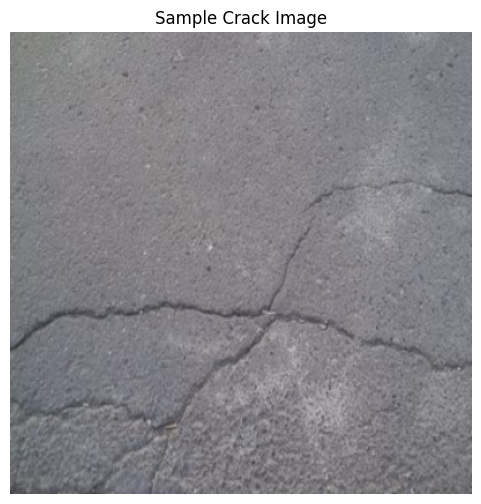

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Crack Image")
plt.show()

### 3.2 Display Corresponding Ground-Truth Mask

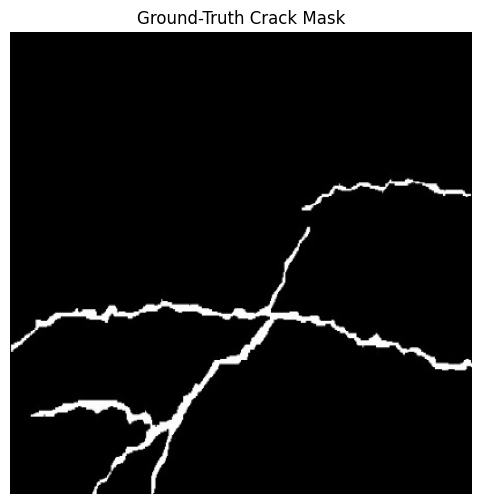

In [11]:
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Ground-Truth Crack Mask")
plt.show()

### 3.3 Overlay Image and Mask

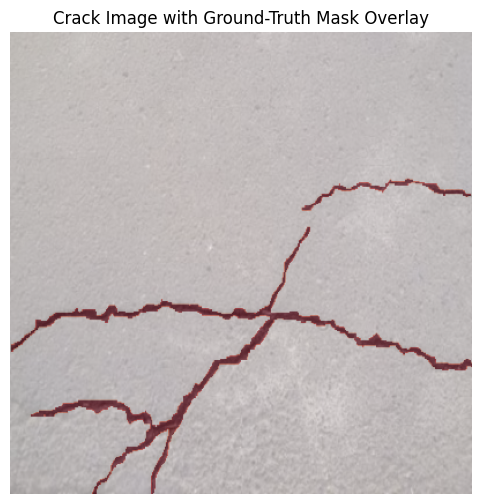

In [12]:
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.imshow(mask, cmap="Reds", alpha=0.5)

plt.axis("off")
plt.title("Crack Image with Ground-Truth Mask Overlay")
plt.show()

## 4. Data Preparation

### 4.1 Define Image and Mask Size

In [13]:
IMAGE_SIZE = (256, 256)

print("Target image size:", IMAGE_SIZE)
print("Input channels: 3")
print("Output channels: 1")

Target image size: (256, 256)
Input channels: 3
Output channels: 1


### 4.2 Define Image and Mask Transformations

In [14]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

image_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

mask_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

print("Image and mask transformations defined.")

Image and mask transformations defined.


### 4.3 Create PyTorch Dataset

In [15]:
class CrackSegmentationDataset(Dataset):
    def __init__(self, hf_dataset, image_transform=None, mask_transform=None):
        self.dataset = hf_dataset
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = Image.open(
            BytesIO(base64.b64decode(sample["image"]))
        ).convert("RGB")

        mask = Image.open(
            BytesIO(base64.b64decode(sample["mask"]))
        ).convert("L")

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        mask = (mask > 0).float()

        return image, mask

In [16]:
train_dataset = CrackSegmentationDataset(
    dataset["train"],
    image_transform=image_transform,
    mask_transform=mask_transform
)

test_dataset = CrackSegmentationDataset(
    dataset["test"],
    image_transform=image_transform,
    mask_transform=mask_transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 7332
Test samples: 1827


### 4.4 Create Train/Validation/Test Splits

In [17]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Training samples: 5865
Validation samples: 1467
Test samples: 1827


### 4.5 Create DataLoaders

In [18]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 16
Training batches: 367
Validation batches: 92
Test batches: 115


## 5. U-Net Architecture

### 5.1 Double Conv Block

In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

### 5.2 Downsampling Block

In [20]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = self.conv(x)
        pooled = self.pool(features)

        return features, pooled

### 5.3 Upsampling Block

In [21]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        return x

### 5.4 U-Net Model

In [22]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = UpBlock(1024, 512)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up1 = UpBlock(128, 64)

        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.output(d1)

### 5.5 Initialize and Test U-Net

In [23]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(DEVICE)

sample_batch = next(iter(train_loader))
sample_images, sample_masks = sample_batch

sample_images = sample_images.to(DEVICE)

with torch.no_grad():
    sample_output = model(sample_images)

print("Device:", DEVICE)
print("Input shape:", sample_images.shape)
print("Output shape:", sample_output.shape)

Device: cuda
Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])


## 6. Training Configuration

### 6.1 Loss Function

In [24]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)

        predictions = predictions.view(predictions.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (predictions * targets).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            / (
                predictions.sum(dim=1)
                + targets.sum(dim=1)
                + self.smooth
            )
        )

        return 1 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()


def combined_loss(predictions, targets):
    return bce_loss(predictions, targets) + dice_loss(predictions, targets)


print("BCE + Dice loss defined.")

BCE + Dice loss defined.


### 6.2 Evaluation Metrics

In [25]:
def dice_coefficient(predictions, targets, threshold=0.5, smooth=1.0):
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(predictions.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (predictions * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        / (
            predictions.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return dice.mean().item()


def iou_score(predictions, targets, threshold=0.5, smooth=1.0):
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(predictions.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (predictions * targets).sum(dim=1)
    union = predictions.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean().item()


print("Dice and IoU metrics defined.")

Dice and IoU metrics defined.


### 6.3 Optimizer

In [26]:
LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)

Optimizer: Adam
Learning rate: 0.0001


### 6.4 Training Configuration

In [27]:
NUM_EPOCHS = 20

best_val_dice = 0.0
best_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

print("Epochs:", NUM_EPOCHS)
print("Best-model criterion: Validation Dice")

Epochs: 20
Best-model criterion: Validation Dice


## 7. Train U-Net

### 7.1 Training Loop

In [29]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coefficient(outputs.detach(), masks)
        total_iou += iou_score(outputs.detach(), masks)

    return (
        total_loss / len(loader),
        total_dice / len(loader),
        total_iou / len(loader)
    )


def validate_one_epoch(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_coefficient(outputs, masks)
            total_iou += iou_score(outputs, masks)

    return (
        total_loss / len(loader),
        total_dice / len(loader),
        total_iou / len(loader)
    )

### 7.2 Train Model

In [31]:
from pathlib import Path

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")

print("Project root:", PROJECT_ROOT)
print("Git repository exists:", (PROJECT_ROOT / ".git").exists())

Project root: /content/concrete-crack-and-fracture-analysis
Git repository exists: True


In [32]:
from pathlib import Path
import time
import pandas as pd
import torch

# Create directories
MODEL_DIR = PROJECT_ROOT / "trained_models"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_unet.pt"

# Training settings
NUM_EPOCHS = 20
best_val_dice = -1.0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        model, val_loader, DEVICE
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    epoch_time = time.time() - start_time

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou
        }, BEST_MODEL_PATH)

        print(f"Best model saved at epoch {epoch}.")

    # Save training history after every epoch
    history_df = pd.DataFrame(history)
    history_df.to_csv(
        METRICS_DIR / "unet_training_history.csv",
        index=False
    )

print("\nTraining completed.")
print("Best validation Dice:", round(best_val_dice, 4))
print("Best model:", BEST_MODEL_PATH)
print("Training history:", METRICS_DIR / "unet_training_history.csv")

Epoch 1/20 | Train Loss: 1.0546 | Val Loss: 0.9697 | Train Dice: 0.2228 | Val Dice: 0.2660 | Train IoU: 0.1702 | Val IoU: 0.1858 | Time: 282.5s
Best model saved at epoch 1.
Epoch 2/20 | Train Loss: 0.9136 | Val Loss: 0.8011 | Train Dice: 0.3240 | Val Dice: 0.3955 | Train IoU: 0.2284 | Val IoU: 0.2870 | Time: 280.5s
Best model saved at epoch 2.
Epoch 3/20 | Train Loss: 0.7339 | Val Loss: 0.6367 | Train Dice: 0.4727 | Val Dice: 0.5445 | Train IoU: 0.3558 | Val IoU: 0.4216 | Time: 283.1s
Best model saved at epoch 3.
Epoch 4/20 | Train Loss: 0.5932 | Val Loss: 0.6021 | Train Dice: 0.5910 | Val Dice: 0.5779 | Train IoU: 0.4705 | Val IoU: 0.4608 | Time: 282.2s
Best model saved at epoch 4.
Epoch 5/20 | Train Loss: 0.5362 | Val Loss: 0.5108 | Train Dice: 0.6295 | Val Dice: 0.6378 | Train IoU: 0.5087 | Val IoU: 0.5182 | Time: 282.2s
Best model saved at epoch 5.
Epoch 6/20 | Train Loss: 0.4967 | Val Loss: 0.5053 | Train Dice: 0.6535 | Val Dice: 0.6447 | Train IoU: 0.5335 | Val IoU: 0.5259 | Time

### 8.1 Load Best Model

In [57]:
# Load best U-Net checkpoint

BEST_MODEL_PATH = PROJECT_ROOT / "trained_models" / "best_unet.pt"

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Best model loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print("Validation Dice:", round(checkpoint["val_dice"], 4))
print("Validation IoU:", round(checkpoint["val_iou"], 4))

Best model loaded successfully.
Best epoch: 19
Validation Dice: 0.7215
Validation IoU: 0.6061


### 8.2 Evaluate Test Set

In [58]:
# Evaluate U-Net on the test set

test_loss, test_dice, test_iou = validate_one_epoch(
    model,
    test_loader,
    DEVICE
)

print("Test Loss:", round(test_loss, 4))
print("Test Dice:", round(test_dice, 4))
print("Test IoU:", round(test_iou, 4))

Test Loss: 0.4283
Test Dice: 0.6855
Test IoU: 0.5659


### 8.3 Display Predicted Masks

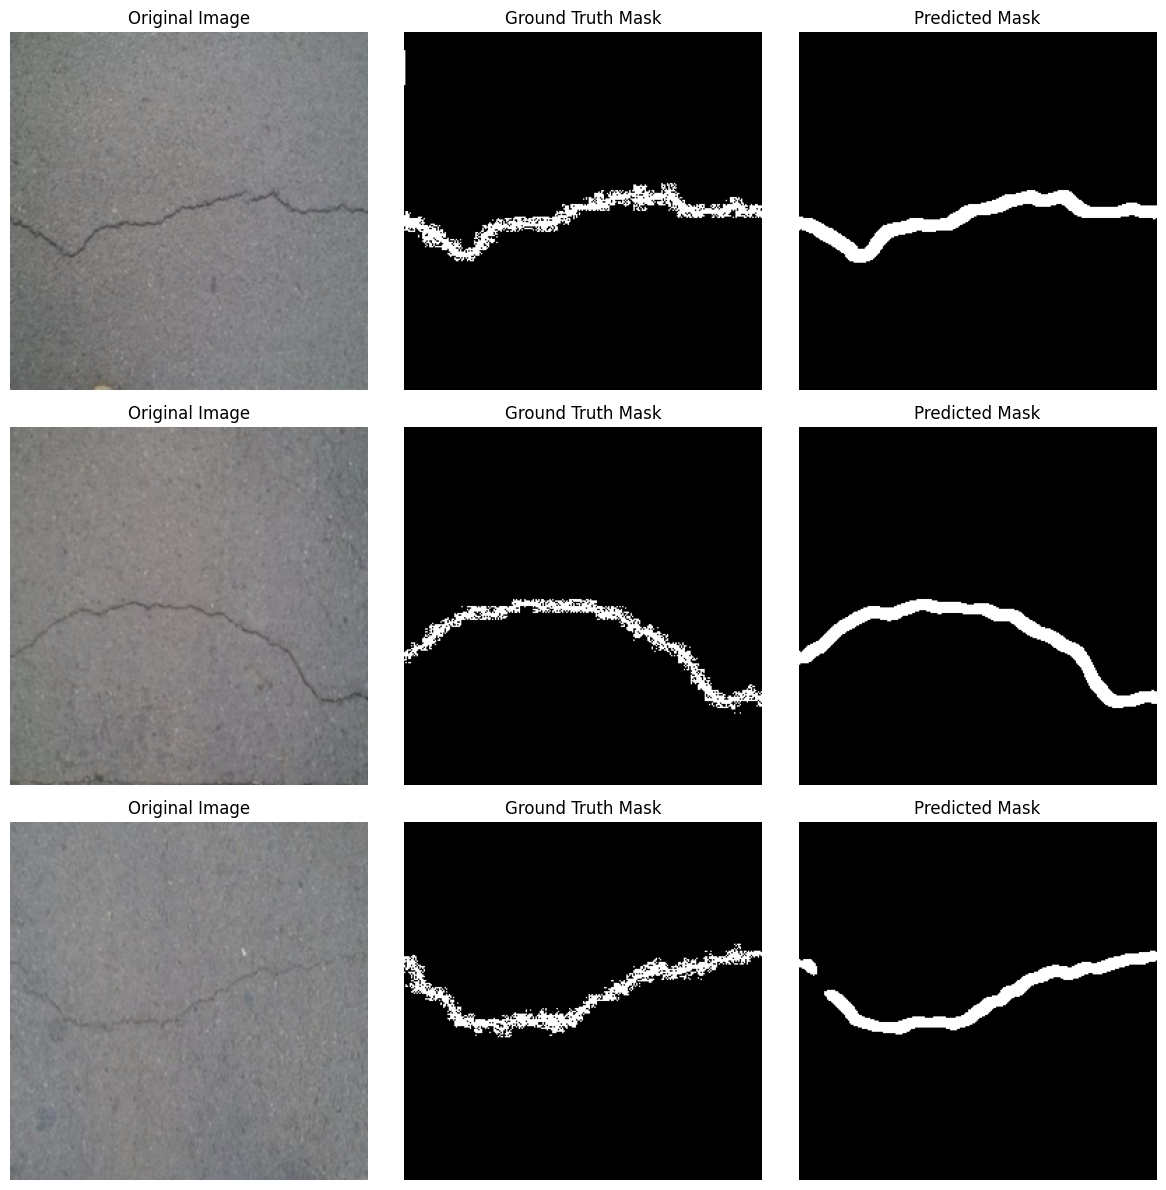

In [59]:
# Display predicted masks

import matplotlib.pyplot as plt
import torch

images, masks = next(iter(test_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    predictions = (torch.sigmoid(outputs) > 0.5).float()

# Display first three samples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    image = images[i].cpu().permute(1, 2, 0).numpy()
    mask = masks[i].cpu().squeeze().numpy()
    prediction = predictions[i].cpu().squeeze().numpy()

    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

### 8.4 Visual Inspection of Multiple Predictions

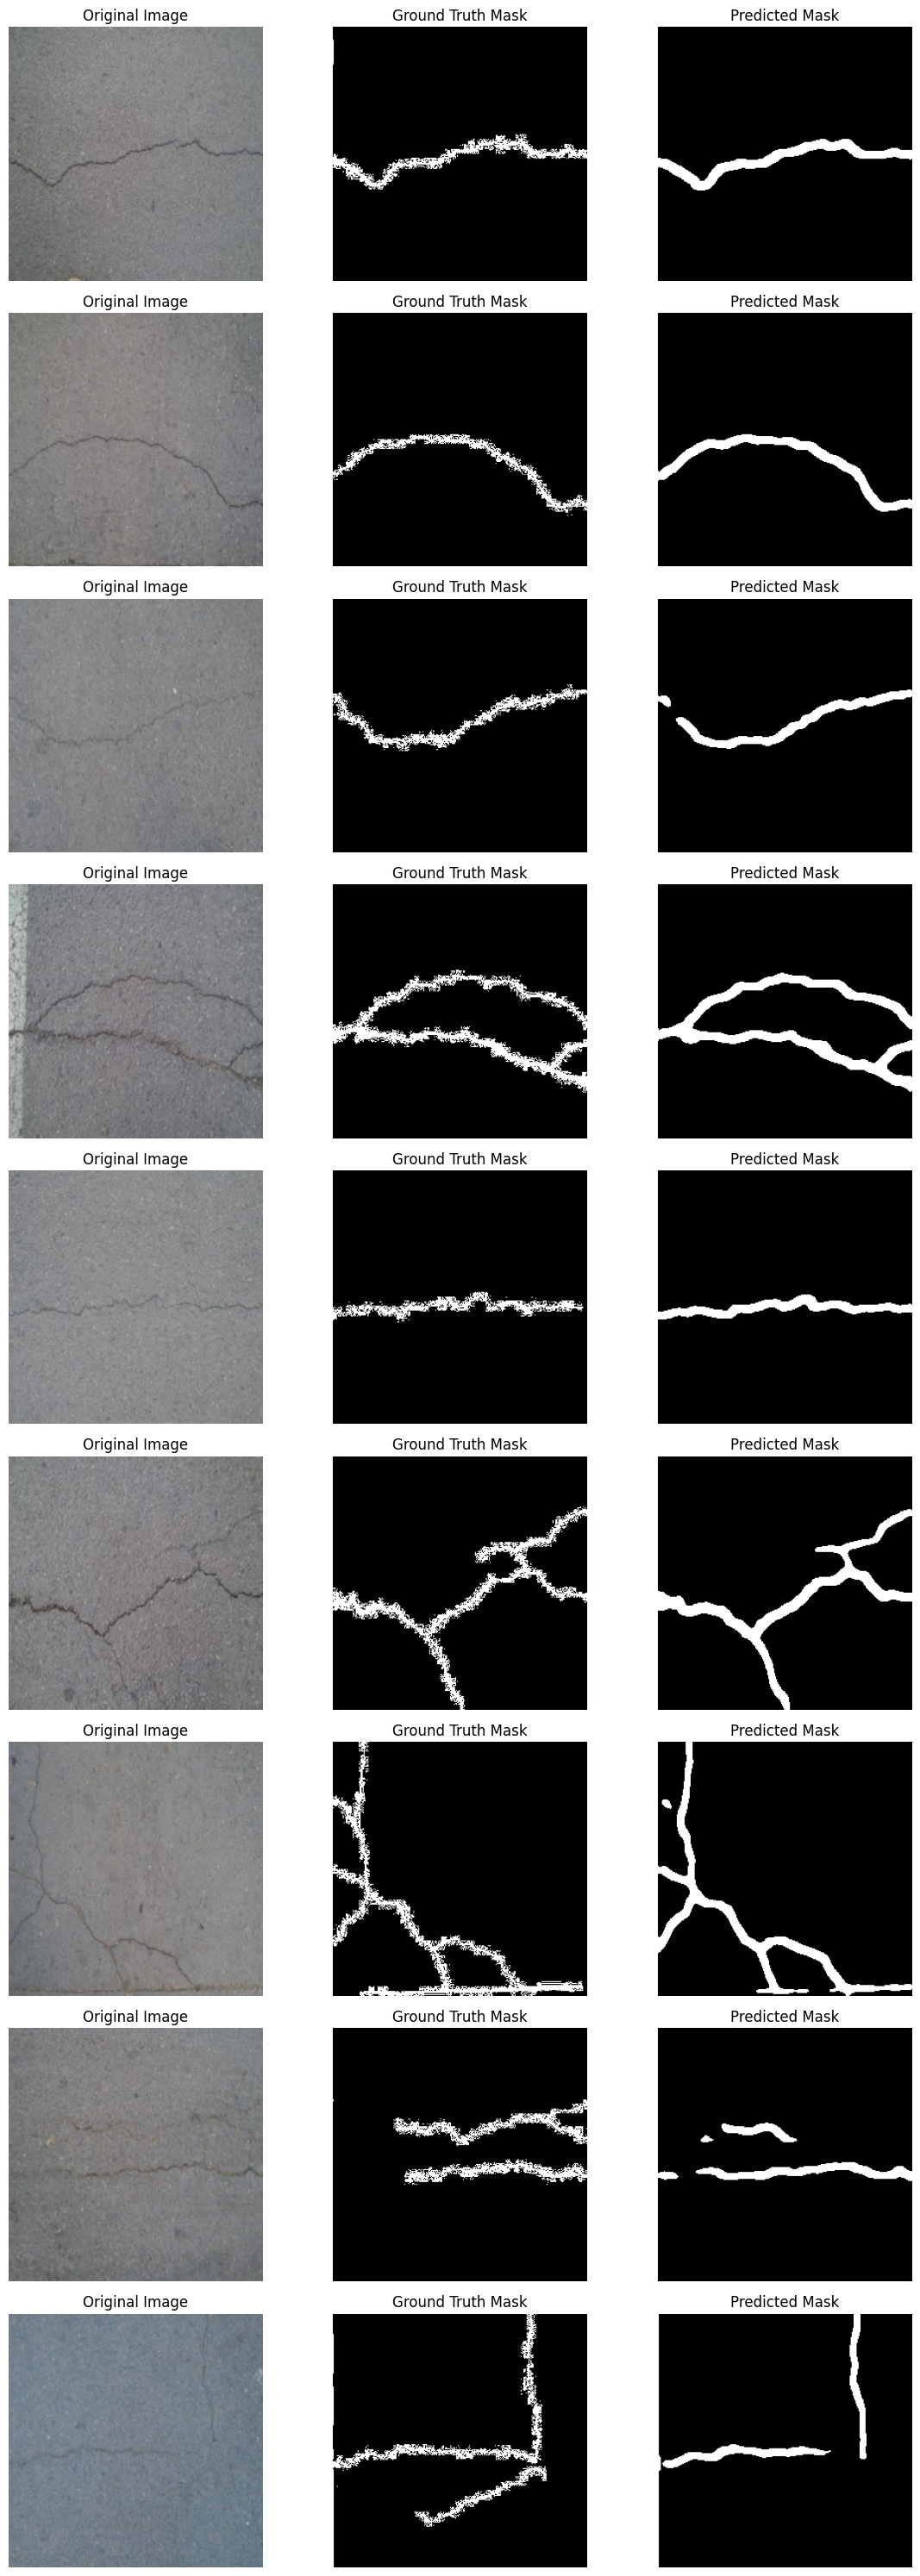

In [60]:
# Visual inspection of multiple predictions

num_samples = 9

images, masks = next(iter(test_loader))

images = images[:num_samples].to(DEVICE)
masks = masks[:num_samples].to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    predictions = (torch.sigmoid(outputs) > 0.5).float()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 30))

for i in range(num_samples):
    image = images[i].cpu().permute(1, 2, 0).numpy()
    image = image * std + mean
    image = np.clip(image, 0, 1)

    mask = masks[i].cpu().squeeze().numpy()
    prediction = predictions[i].cpu().squeeze().numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 9. Apply U-Net to SDNET2018

### 9.1 Extract SDNET2018

In [61]:
from pathlib import Path
import zipfile

SDNET_ZIP = Path("/content/sdnet2018.zip")
SDNET_ROOT = Path("/content/sdnet2018")

print("ZIP exists:", SDNET_ZIP.exists())

if not SDNET_ROOT.exists():
    with zipfile.ZipFile(SDNET_ZIP, "r") as zip_ref:
        zip_ref.extractall(SDNET_ROOT)

print("Extraction complete.")
print("SDNET2018 folder:", SDNET_ROOT)

ZIP exists: True
Extraction complete.
SDNET2018 folder: /content/sdnet2018


In [62]:
# Inspect extracted folders

for path in SDNET_ROOT.iterdir():
    print(path)

/content/sdnet2018/sdnet2018


### 9.2 Verify SDNET2018 structure

In [64]:
from pathlib import Path

SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

for category in ["deck", "pavement", "wall"]:
    category_path = SDNET_ROOT / category

    print(f"\n{category.upper()}")
    for item in list(category_path.iterdir())[:10]:
        print(" ", item)


DECK
  /content/sdnet2018/sdnet2018/deck/crack_dataset
  /content/sdnet2018/sdnet2018/deck/uncrack_dataset

PAVEMENT
  /content/sdnet2018/sdnet2018/pavement/crack_dataset
  /content/sdnet2018/sdnet2018/pavement/uncrack_dataset

WALL
  /content/sdnet2018/sdnet2018/wall/crack_dataset
  /content/sdnet2018/sdnet2018/wall/uncrack_dataset


### 9.2 Count and verify the images

In [65]:
from pathlib import Path

SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

total_images = 0

for category in ["deck", "pavement", "wall"]:
    crack_path = SDNET_ROOT / category / "crack_dataset"
    uncrack_path = SDNET_ROOT / category / "uncrack_dataset"

    crack_images = list(crack_path.glob("*.jpg"))
    uncrack_images = list(uncrack_path.glob("*.jpg"))

    print(f"\n{category.upper()}")
    print("Cracked:", len(crack_images))
    print("Uncracked:", len(uncrack_images))

    total_images += len(crack_images) + len(uncrack_images)

print("\nTotal images:", total_images)


DECK
Cracked: 2025
Uncracked: 11595

PAVEMENT
Cracked: 2608
Uncracked: 21726

WALL
Cracked: 3851
Uncracked: 14287

Total images: 56092


### 9.3 Select an SDNET2018 image and prepare it for U-Net

In [66]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt

# Select one cracked SDNET2018 image
sample_image_path = next(
    (SDNET_ROOT / "deck" / "crack_dataset").glob("*.jpg")
)

# Load image
image = Image.open(sample_image_path).convert("RGB")

print("Image path:", sample_image_path)
print("Original size:", image.size)

# Apply U-Net preprocessing
image_tensor = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])(image)

# Add batch dimension and move to GPU
input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

print("Model input shape:", input_tensor.shape)
print("Device:", input_tensor.device)

Image path: /content/sdnet2018/sdnet2018/deck/crack_dataset/7017-33.jpg
Original size: (256, 256)
Model input shape: torch.Size([1, 3, 256, 256])
Device: cuda:0


### 9.4 Generate the Predicted Crack Mask

In [67]:
# Generate predicted crack mask

with torch.no_grad():
    output = model(input_tensor)
    probability = torch.sigmoid(output)
    predicted_mask = (probability > 0.5).float()

print("Output shape:", output.shape)
print("Predicted mask shape:", predicted_mask.shape)
print("Crack pixels:", int(predicted_mask.sum().item()))
print("Total pixels:", predicted_mask.numel())

Output shape: torch.Size([1, 1, 256, 256])
Predicted mask shape: torch.Size([1, 1, 256, 256])
Crack pixels: 1332
Total pixels: 65536


### 9.5 Display the Result

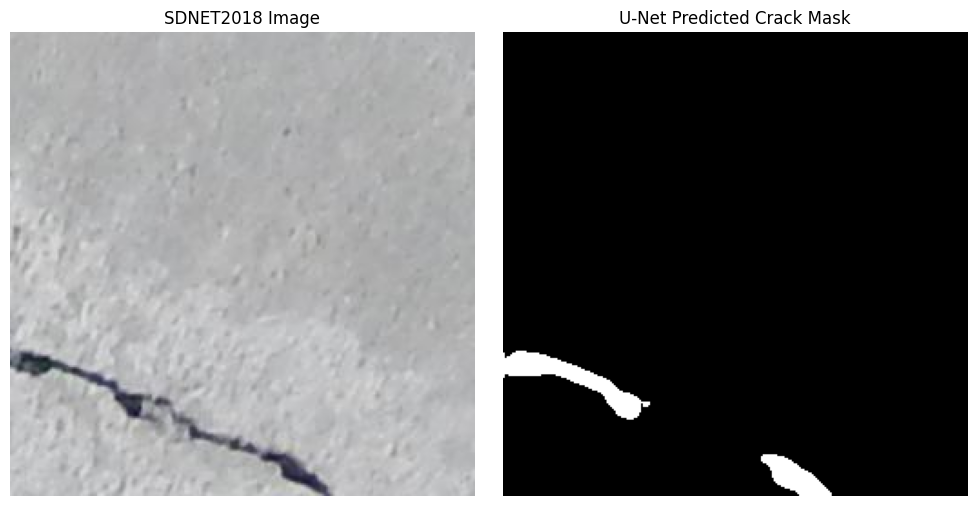

In [68]:
# Display SDNET2018 image and predicted mask

image_array = np.array(image)

mask_array = predicted_mask.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_array)
axes[0].set_title("SDNET2018 Image")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("U-Net Predicted Crack Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 9.6 Inspect Multiple SDNET2018 Predictions.

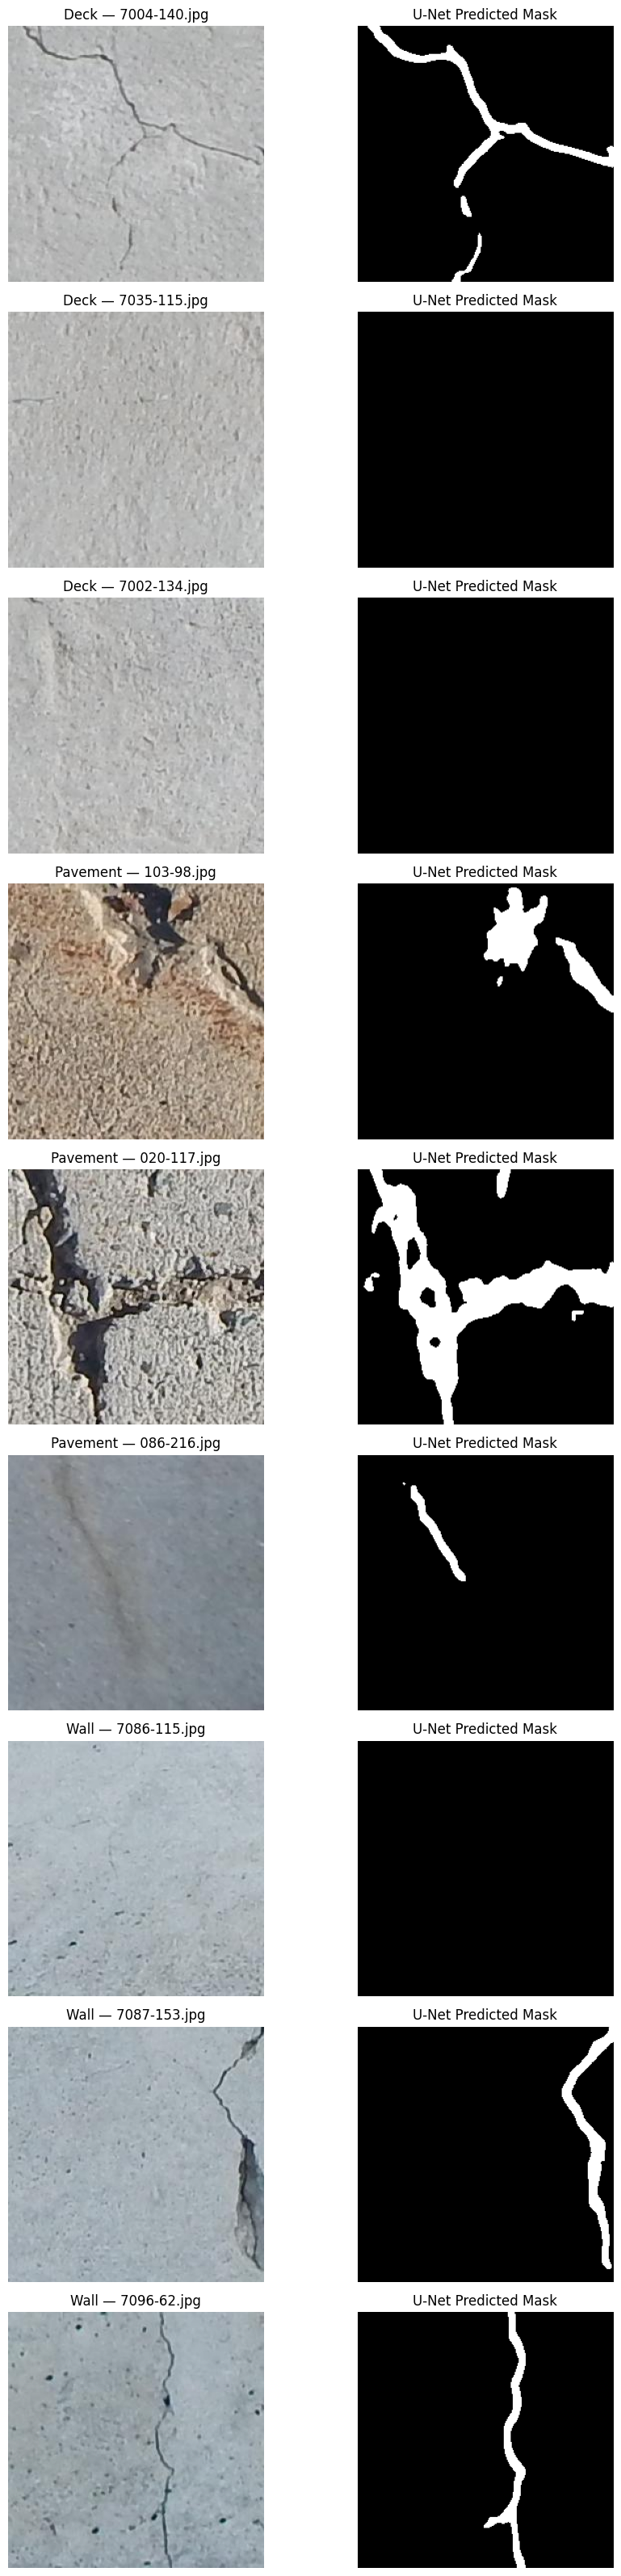

In [69]:
# Inspect multiple SDNET2018 predictions

import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

random.seed(42)

categories = ["deck", "pavement", "wall"]
samples = []

for category in categories:
    crack_images = list(
        (SDNET_ROOT / category / "crack_dataset").glob("*.jpg")
    )
    samples.extend(
        [(category, path) for path in random.sample(crack_images, 3)]
    )

fig, axes = plt.subplots(9, 2, figsize=(10, 32))

for i, (category, image_path) in enumerate(samples):
    image = Image.open(image_path).convert("RGB")

    image_tensor = transforms.Compose([
        transforms.Resize(
            (256, 256),
            interpolation=InterpolationMode.BILINEAR
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])(image)

    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        probability = torch.sigmoid(output)
        predicted_mask = (probability > 0.5).float()

    mask_array = predicted_mask.squeeze().cpu().numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"{category.capitalize()} — {image_path.name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_array, cmap="gray")
    axes[i, 1].set_title("U-Net Predicted Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 10. Crack Morphology Extraction

### 10.1 Clean Predicted Mask

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clean_crack_mask(mask, min_area=20):
    mask_uint8 = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_uint8,
        connectivity=8
    )

    cleaned = np.zeros_like(mask_uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == label] = 1

    return cleaned

In [71]:
cleaned_mask = clean_crack_mask(mask_array)

print("Original crack pixels:", int(mask_array.sum()))
print("Cleaned crack pixels:", int(cleaned_mask.sum()))

Original crack pixels: 2389
Cleaned crack pixels: 2389


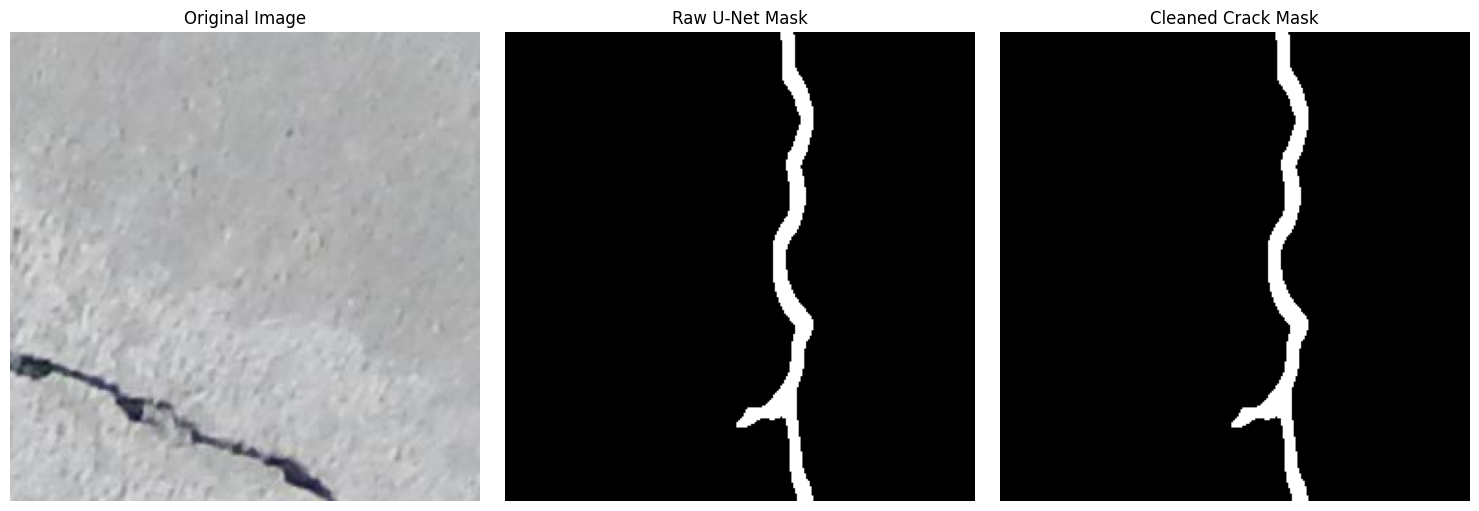

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_array)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Raw U-Net Mask")
axes[1].axis("off")

axes[2].imshow(cleaned_mask, cmap="gray")
axes[2].set_title("Cleaned Crack Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [73]:
predicted_mask = (probability > 0.5).float()

Minimum probability: 3.6230404e-11
Maximum probability: 0.9908199
Mean probability: 0.035274725


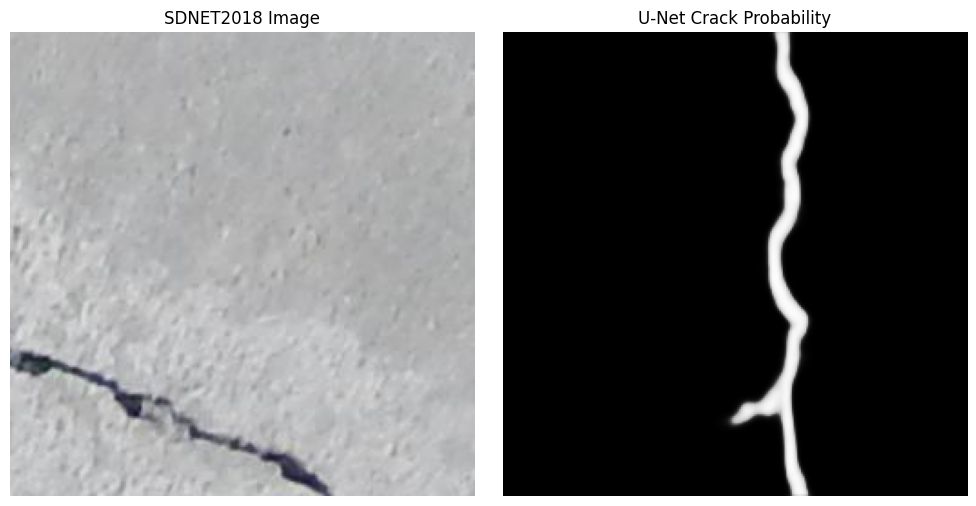

In [74]:
# Inspect U-Net prediction confidence

probability_array = probability.squeeze().cpu().numpy()

print("Minimum probability:", probability_array.min())
print("Maximum probability:", probability_array.max())
print("Mean probability:", probability_array.mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_array)
axes[0].set_title("SDNET2018 Image")
axes[0].axis("off")

axes[1].imshow(probability_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("U-Net Crack Probability")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 10.1 Morphology Mask Quality Control

### 10.1 Mask Quality Control

In [75]:
import cv2
import numpy as np

def mask_quality_score(image, mask):
    # Convert image to grayscale
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)

    mask = (mask > 0).astype(np.uint8)

    if mask.sum() == 0:
        return {
            "crack_pixels": 0,
            "area_ratio": 0.0,
            "contrast": 0.0
        }

    # Dilate mask to obtain surrounding region
    kernel = np.ones((11, 11), np.uint8)
    surrounding = cv2.dilate(mask, kernel, iterations=1)

    # Exclude predicted crack pixels
    surrounding = surrounding - mask

    crack_pixels = gray[mask == 1]
    surrounding_pixels = gray[surrounding == 1]

    if len(surrounding_pixels) == 0:
        contrast = 0.0
    else:
        contrast = (
            surrounding_pixels.mean()
            - crack_pixels.mean()
        )

    area_ratio = mask.sum() / mask.size

    return {
        "crack_pixels": int(mask.sum()),
        "area_ratio": float(area_ratio),
        "contrast": float(contrast)
    }

In [76]:
quality = mask_quality_score(
    image,
    mask_array
)

print("Crack pixels:", quality["crack_pixels"])
print("Area ratio:", round(quality["area_ratio"], 4))
print("Local contrast:", round(quality["contrast"], 2))

Crack pixels: 2389
Area ratio: 0.0365
Local contrast: 25.08


In [77]:
# Recreate one image-mask pair for quality control

from PIL import Image
import numpy as np
import torch

qc_image_path = SDNET_ROOT / "deck" / "crack_dataset" / "7017-33.jpg"

qc_image = Image.open(qc_image_path).convert("RGB")

qc_transform = transforms.Compose([
    transforms.Resize(
        (256, 256),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

qc_input = qc_transform(qc_image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    qc_output = model(qc_input)
    qc_probability = torch.sigmoid(qc_output)
    qc_mask = (qc_probability > 0.5).float()

qc_image_array = np.array(qc_image)
qc_mask_array = qc_mask.squeeze().cpu().numpy()

quality = mask_quality_score(
    qc_image,
    qc_mask_array
)

print("Image:", qc_image_path.name)
print("Crack pixels:", quality["crack_pixels"])
print("Area ratio:", round(quality["area_ratio"], 4))
print("Local contrast:", round(quality["contrast"], 2))

Image: 7017-33.jpg
Crack pixels: 1332
Area ratio: 0.0203
Local contrast: 72.48


### 10.2 Reload U-Net Model

In [5]:
# Define U-Net architecture

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)

        return x


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = UpBlock(1024, 512)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up1 = UpBlock(128, 64)

        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.output(d1)


model = UNet().to(DEVICE)

# Load best checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("U-Net loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print("Validation Dice:", round(checkpoint["val_dice"], 4))
print("Validation IoU:", round(checkpoint["val_iou"], 4))

U-Net loaded successfully.
Best epoch: 19
Validation Dice: 0.7215
Validation IoU: 0.6061


### 10.4 Generate SDNET2018 Prediction

In [6]:
# Generate prediction for one SDNET2018 image

image_path = SDNET_ROOT / "deck" / "crack_dataset" / "7017-33.jpg"

image = Image.open(image_path).convert("RGB")

image_transform = transforms.Compose([
    transforms.Resize(
        (256, 256),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = image_transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = model(input_tensor)
    probability = torch.sigmoid(output)
    predicted_mask = (probability > 0.5).float()

mask_array = predicted_mask.squeeze().cpu().numpy()

print("Image:", image_path.name)
print("Image size:", image.size)
print("Mask shape:", mask_array.shape)
print("Crack pixels:", int(mask_array.sum()))
print("Area ratio:", round(mask_array.mean(), 4))

Image: 7017-33.jpg
Image size: (256, 256)
Mask shape: (256, 256)
Crack pixels: 1332
Area ratio: 0.0203


### 10.5 Clean the Predicted Mask

In [7]:
# Clean predicted crack mask

def clean_crack_mask(mask, min_area=20):
    mask = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label] = 1

    return cleaned_mask


cleaned_mask = clean_crack_mask(
    mask_array,
    min_area=20
)

print("Raw crack pixels:", int(mask_array.sum()))
print("Cleaned crack pixels:", int(cleaned_mask.sum()))
print("Raw area ratio:", round(mask_array.mean(), 4))
print("Cleaned area ratio:", round(cleaned_mask.mean(), 4))

Raw crack pixels: 1332
Cleaned crack pixels: 1332
Raw area ratio: 0.0203
Cleaned area ratio: 0.0203


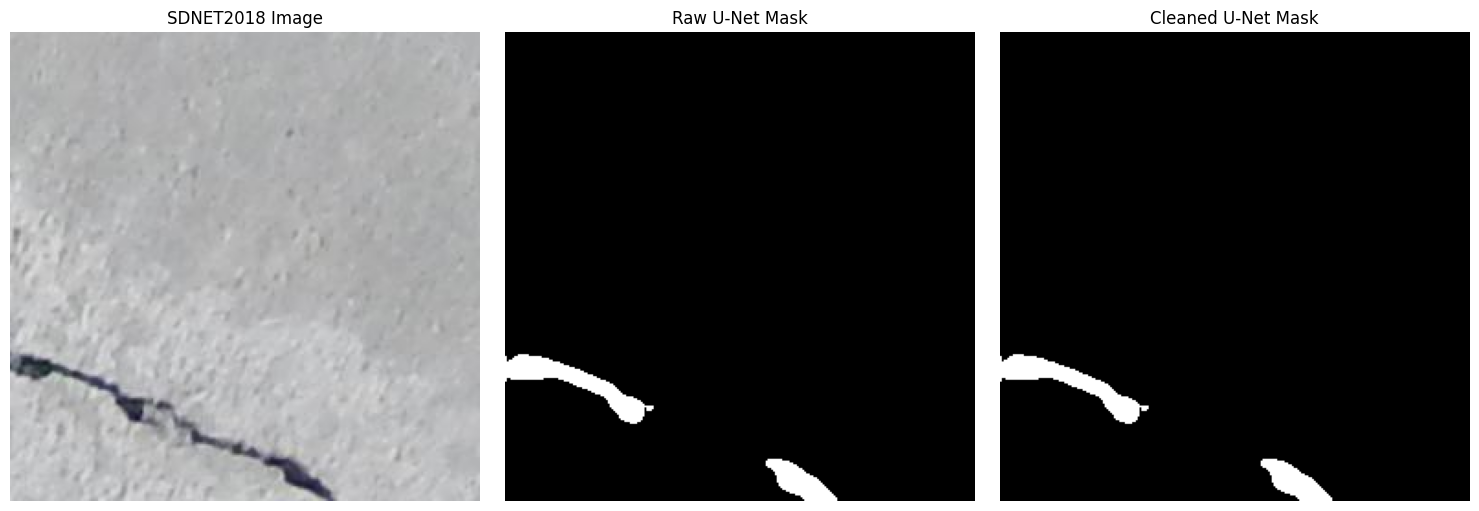

In [9]:
# Compare raw and cleaned masks

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("SDNET2018 Image")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Raw U-Net Mask")
axes[1].axis("off")

axes[2].imshow(cleaned_mask, cmap="gray")
axes[2].set_title("Cleaned U-Net Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 10.6 Crack Area

In [10]:
# Calculate predicted crack area

total_pixels = cleaned_mask.size
crack_pixels = int(cleaned_mask.sum())

crack_area_ratio = crack_pixels / total_pixels
crack_area_percentage = crack_area_ratio * 100

print("Total pixels:", total_pixels)
print("Predicted crack pixels:", crack_pixels)
print("Crack area ratio:", round(crack_area_ratio, 4))
print("Crack area percentage:", round(crack_area_percentage, 2), "%")

Total pixels: 65536
Predicted crack pixels: 1332
Crack area ratio: 0.0203
Crack area percentage: 2.03 %


### 10.7 Crack Length

In [11]:
# Skeletonize predicted crack mask

from skimage.morphology import skeletonize

skeleton = skeletonize(cleaned_mask > 0)

print("Skeleton pixels:", int(skeleton.sum()))

Skeleton pixels: 127


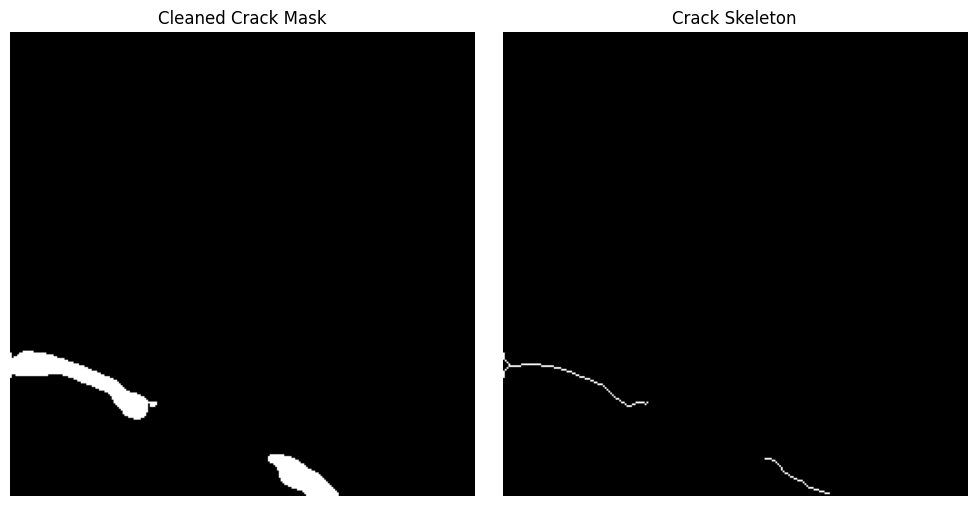

In [12]:
# Display crack skeleton

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cleaned_mask, cmap="gray")
axes[0].set_title("Cleaned Crack Mask")
axes[0].axis("off")

axes[1].imshow(skeleton, cmap="gray")
axes[1].set_title("Crack Skeleton")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 10.8 Calculate Crack Length

In [13]:
# Calculate crack skeleton length in pixels

def skeleton_length(skeleton):
    skeleton = skeleton.astype(np.uint8)

    length = 0.0

    # Horizontal and vertical connections
    length += np.sum(skeleton[:, :-1] & skeleton[:, 1:])
    length += np.sum(skeleton[:-1, :] & skeleton[1:, :])

    # Diagonal connections
    diagonal_1 = skeleton[:-1, :-1] & skeleton[1:, 1:]
    diagonal_2 = skeleton[:-1, 1:] & skeleton[1:, :-1]

    length += np.sum(diagonal_1) * np.sqrt(2)
    length += np.sum(diagonal_2) * np.sqrt(2)

    return length


crack_length_pixels = skeleton_length(skeleton)

print("Crack skeleton length:", round(crack_length_pixels, 2), "pixels")

Crack skeleton length: 147.95 pixels


## 10.9  Crack Width

In [14]:
# Calculate crack width from the distance transform

from scipy import ndimage

distance = ndimage.distance_transform_edt(cleaned_mask)

width_map = 2 * distance

crack_widths = width_map[cleaned_mask > 0]

if len(crack_widths) > 0:
    mean_width_pixels = crack_widths.mean()
    max_width_pixels = crack_widths.max()
else:
    mean_width_pixels = 0.0
    max_width_pixels = 0.0

print("Mean crack width:", round(mean_width_pixels, 2), "pixels")
print("Maximum crack width:", round(max_width_pixels, 2), "pixels")

Mean crack width: 6.3 pixels
Maximum crack width: 16.0 pixels


### 10.10 Crack Orientation

In [15]:
# Calculate dominant crack orientation

def dominant_orientation(skeleton):
    y, x = np.where(skeleton > 0)

    if len(x) < 2:
        return np.nan

    # Coordinates for PCA
    coordinates = np.column_stack((x, y))

    # Center coordinates
    centered = coordinates - coordinates.mean(axis=0)

    # Principal component analysis
    covariance = np.cov(centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    # Principal direction
    direction = eigenvectors[:, np.argmax(eigenvalues)]

    angle = np.degrees(np.arctan2(direction[1], direction[0]))

    # Convert to 0–180 degrees
    angle = angle % 180

    return angle


orientation = dominant_orientation(skeleton)

print("Dominant crack orientation:", round(orientation, 2), "degrees")

Dominant crack orientation: 22.92 degrees


### 10.11 Crack Branching

In [16]:
# Calculate crack branching

def count_branch_points(skeleton):
    skeleton = skeleton.astype(np.uint8)

    kernel = np.ones((3, 3), dtype=np.uint8)
    neighbour_count = cv2.filter2D(
        skeleton,
        -1,
        kernel
    ) - skeleton

    branch_points = (
        (skeleton == 1) &
        (neighbour_count >= 3)
    )

    return int(branch_points.sum())


branching_points = count_branch_points(skeleton)

print("Branching points:", branching_points)

Branching points: 5


### 10.12 Create the Morphology Dataset

In [18]:
# Create a function for extracting crack morphology

def extract_crack_morphology(image, mask):
    mask = (mask > 0).astype(np.uint8)

    crack_pixels = int(mask.sum())
    total_pixels = mask.size

    if crack_pixels == 0:
        return {
            "crack_area_ratio": 0.0,
            "crack_area_percentage": 0.0,
            "crack_length_pixels": 0.0,
            "mean_width_pixels": 0.0,
            "max_width_pixels": 0.0,
            "dominant_orientation_deg": np.nan,
            "branching_points": 0
        }

    # Skeleton
    skeleton = skeletonize(mask > 0)

    # Length
    length = skeleton_length(skeleton)

    # Width
    distance = ndimage.distance_transform_edt(mask)
    width_map = 2 * distance
    widths = width_map[mask > 0]

    mean_width = widths.mean()
    max_width = widths.max()

    # Orientation
    orientation = dominant_orientation(skeleton)

    # Branching
    branching = count_branch_points(skeleton)

    return {
        "crack_area_ratio": crack_pixels / total_pixels,
        "crack_area_percentage": (crack_pixels / total_pixels) * 100,
        "crack_length_pixels": length,
        "mean_width_pixels": mean_width,
        "max_width_pixels": max_width,
        "dominant_orientation_deg": orientation,
        "branching_points": branching
    }

### 10.13 Test Morphology Extraction

In [21]:
# Test morphology extraction on one image from each category

import random

random.seed(42)

test_samples = []

for category in ["deck", "pavement", "wall"]:
    crack_images = list(
        (SDNET_ROOT / category / "crack_dataset").glob("*.jpg")
    )

    image_path = random.choice(crack_images)

    test_samples.append((category, image_path))


morphology_results = []

for category, image_path in test_samples:

    image = Image.open(image_path).convert("RGB")

    input_tensor = image_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        probability = torch.sigmoid(output)
        predicted_mask = (probability > 0.5).float()

    mask = predicted_mask.squeeze().cpu().numpy()

    # Clean predicted mask
    mask = clean_crack_mask(mask, min_area=20)

    # Extract morphology
    features = extract_crack_morphology(image, mask)

    features["category"] = category
    features["image_name"] = image_path.name

    morphology_results.append(features)


morphology_test_df = pd.DataFrame(morphology_results)

morphology_test_df = morphology_test_df[
    [
        "category",
        "image_name",
        "crack_area_ratio",
        "crack_area_percentage",
        "crack_length_pixels",
        "mean_width_pixels",
        "max_width_pixels",
        "dominant_orientation_deg",
        "branching_points"
    ]
]

morphology_test_df

,category,image_name,crack_area_ratio,crack_area_percentage,crack_length_pixels,mean_width_pixels,max_width_pixels,dominant_orientation_deg,branching_points
0,deck,7004-140.jpg,0.056732,5.673218,515.629509,4.946703,12.806248,52.985430,15
1,pavement,071-61.jpg,0.014938,1.493835,124.083261,4.948032,10.000000,164.423442,1
2,wall,7070-42.jpg,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0


### 10.14 Build the 6000-Image Morphology Dataset

In [30]:
# Build a larger balanced SDNET2018 morphology dataset

SAMPLE_SIZE = 1000
categories = ["deck", "pavement", "wall"]

morphology_results = []

for category in categories:

    crack_images = list(
        (SDNET_ROOT / category / "crack_dataset").glob("*.jpg")
    )

    uncrack_images = list(
        (SDNET_ROOT / category / "uncrack_dataset").glob("*.jpg")
    )

    selected_images = (
        [(path, "cracked") for path in random.sample(crack_images, SAMPLE_SIZE)]
        + [(path, "uncracked") for path in random.sample(uncrack_images, SAMPLE_SIZE)]
    )

    for image_path, label in tqdm(
        selected_images,
        desc=f"Processing {category}"
    ):

        image = Image.open(image_path).convert("RGB")

        input_tensor = image_transform(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            probability = torch.sigmoid(output)
            predicted_mask = (probability > 0.5).float()

        mask = predicted_mask.squeeze().cpu().numpy()

        mask = clean_crack_mask(mask, min_area=20)

        features = extract_crack_morphology(image, mask)

        features["category"] = category
        features["image_name"] = image_path.name
        features["label"] = label

        morphology_results.append(features)


morphology_df = pd.DataFrame(morphology_results)

morphology_df["predicted_crack_present"] = (
    morphology_df["crack_area_ratio"] > 0
).astype(int)

morphology_df = morphology_df[
    [
        "category",
        "image_name",
        "label",
        "predicted_crack_present",
        "crack_area_ratio",
        "crack_area_percentage",
        "crack_length_pixels",
        "mean_width_pixels",
        "max_width_pixels",
        "dominant_orientation_deg",
        "branching_points"
    ]
]

print("\nMorphology dataset created.")
print("Rows:", len(morphology_df))
print("Columns:", len(morphology_df.columns))

print("\nImages by category:")
print(morphology_df["category"].value_counts())

print("\nImages by category and label:")
print(
    morphology_df.groupby(["category", "label"]).size()
)

Processing deck:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing pavement:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing wall:   0%|          | 0/2000 [00:00<?, ?it/s]


Morphology dataset created.
Rows: 6000
Columns: 11

Images by category:
category
deck        2000
pavement    2000
wall        2000
Name: count, dtype: int64

Images by category and label:
category  label    
deck      cracked      1000
          uncracked    1000
pavement  cracked      1000
          uncracked    1000
wall      cracked      1000
          uncracked    1000
dtype: int64


### 10.15 Check Segmentation Detection Status

In [31]:
# Check U-Net crack detection on the 6,000-image sample

print("Overall predicted crack status:")
print(
    morphology_df["predicted_crack_present"]
    .value_counts()
    .rename(index={
        0: "No predicted crack",
        1: "Predicted crack"
    })
)

print("\nPredicted crack status by true label:")
print(
    pd.crosstab(
        morphology_df["label"],
        morphology_df["predicted_crack_present"],
        rownames=["True label"],
        colnames=["Predicted crack"]
    )
)

print("\nPredicted crack status by category:")
print(
    pd.crosstab(
        morphology_df["category"],
        morphology_df["predicted_crack_present"],
        rownames=["Category"],
        colnames=["Predicted crack"]
    )
)

print("\nPredicted crack rate by category and true label:")
print(
    morphology_df.groupby(
        ["category", "label"]
    )["predicted_crack_present"]
    .mean()
    .mul(100)
    .round(2)
)

Overall predicted crack status:
predicted_crack_present
No predicted crack    3399
Predicted crack       2601
Name: count, dtype: int64

Predicted crack status by true label:
Predicted crack     0     1
True label                 
cracked          1104  1896
uncracked        2295   705

Predicted crack status by category:
Predicted crack     0     1
Category                   
deck             1405   595
pavement          751  1249
wall             1243   757

Predicted crack rate by category and true label:
category  label    
deck      cracked      49.5
          uncracked    10.0
pavement  cracked      89.5
          uncracked    35.4
wall      cracked      50.6
          uncracked    25.1
Name: predicted_crack_present, dtype: float64


### 10.16 final morphology-analysis dataset

In [32]:
# Create the dataset for predicted crack morphology analysis

morphology_positive_df = morphology_df[
    morphology_df["predicted_crack_present"] == 1
].copy()

print("Images with predicted crack regions:", len(morphology_positive_df))

print("\nBy category:")
print(
    morphology_positive_df["category"].value_counts()
)

print("\nBy category and true label:")
print(
    morphology_positive_df.groupby(
        ["category", "label"]
    ).size()
)

print("\nMorphology variables:")
print(
    morphology_positive_df[
        [
            "crack_area_percentage",
            "crack_length_pixels",
            "mean_width_pixels",
            "max_width_pixels",
            "dominant_orientation_deg",
            "branching_points"
        ]
    ].describe().T
)

Images with predicted crack regions: 2601

By category:
category
pavement    1249
wall         757
deck         595
Name: count, dtype: int64

By category and true label:
category  label    
deck      cracked      495
          uncracked    100
pavement  cracked      895
          uncracked    354
wall      cracked      506
          uncracked    251
dtype: int64

Morphology variables:
                           count        mean         std       min        25%  \
crack_area_percentage     2601.0    3.054099    3.257955  0.030518   0.639343   
crack_length_pixels       2601.0  221.599577  159.800157  1.414214  89.426407   
mean_width_pixels         2601.0    5.871541    2.920123  2.000000   4.475949   
max_width_pixels          2601.0   15.762875   10.574464  2.000000  10.000000   
dominant_orientation_deg  2601.0   92.519465   51.481580  0.000000  50.001910   
branching_points          2601.0    3.567859    6.669341  0.000000   0.000000   

                                 50%       

### 10.17 Distribution of Predicted Crack Area

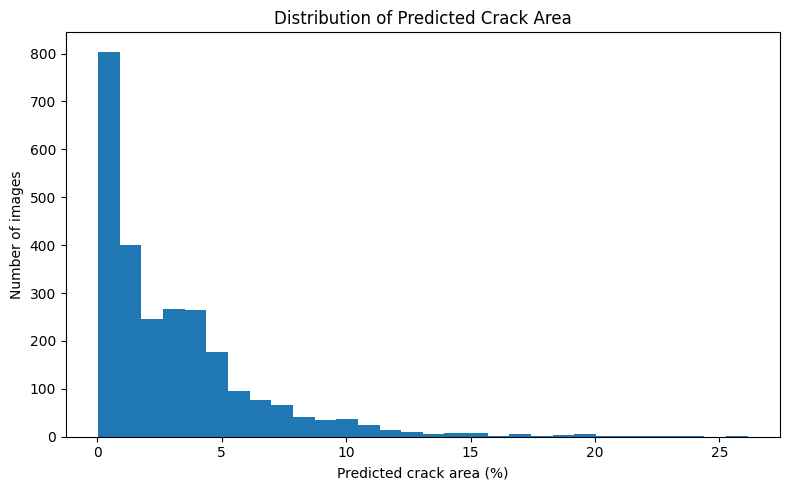

In [33]:
# Distribution of predicted crack area

plt.figure(figsize=(8, 5))

plt.hist(
    morphology_positive_df["crack_area_percentage"],
    bins=30
)

plt.xlabel("Predicted crack area (%)")
plt.ylabel("Number of images")
plt.title("Distribution of Predicted Crack Area")

plt.tight_layout()
plt.show()

### 10.18 Distribution of Predicted Crack Length

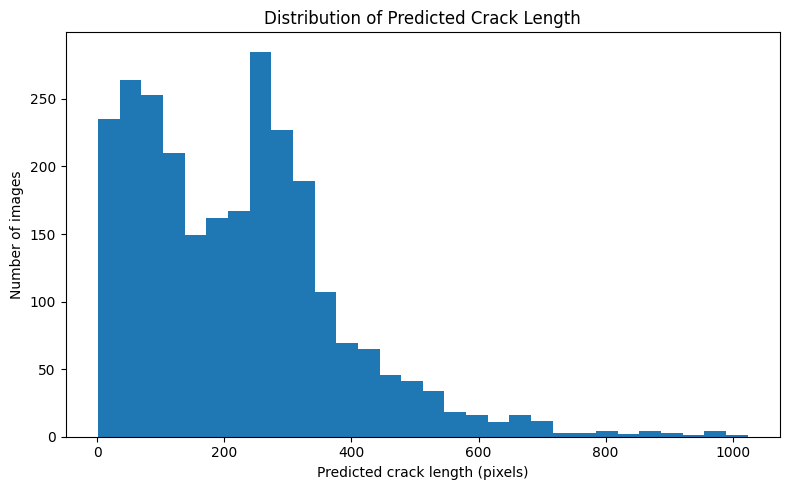

In [34]:
# Distribution of predicted crack length

plt.figure(figsize=(8, 5))

plt.hist(
    morphology_positive_df["crack_length_pixels"],
    bins=30
)

plt.xlabel("Predicted crack length (pixels)")
plt.ylabel("Number of images")
plt.title("Distribution of Predicted Crack Length")

plt.tight_layout()
plt.show()

### 10.18 Distribution of Predicted Mean Crack Width

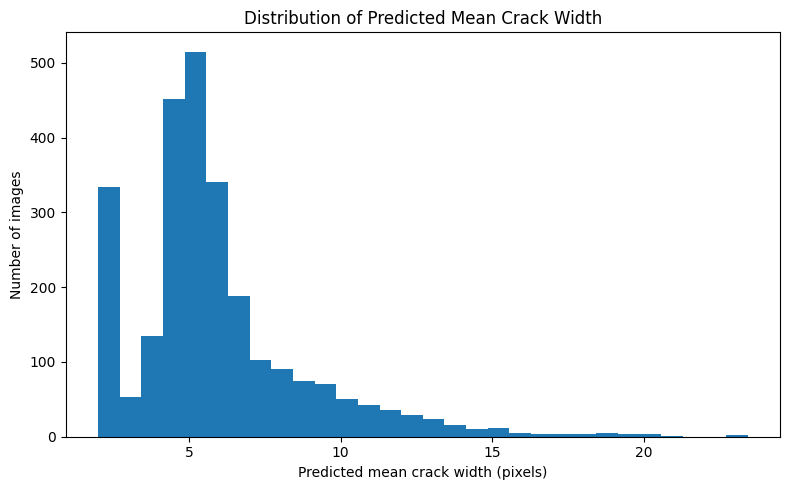

In [35]:
# Distribution of predicted mean crack width

plt.figure(figsize=(8, 5))

plt.hist(
    morphology_positive_df["mean_width_pixels"],
    bins=30
)

plt.xlabel("Predicted mean crack width (pixels)")
plt.ylabel("Number of images")
plt.title("Distribution of Predicted Mean Crack Width")

plt.tight_layout()
plt.show()

### 10.19 Distribution of Predicted Maximum Crack Width

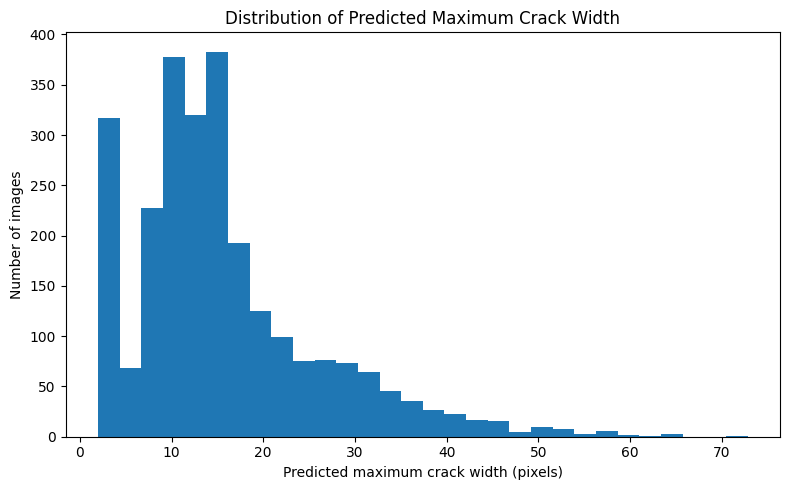

In [36]:
# Distribution of predicted maximum crack width

plt.figure(figsize=(8, 5))

plt.hist(
    morphology_positive_df["max_width_pixels"],
    bins=30
)

plt.xlabel("Predicted maximum crack width (pixels)")
plt.ylabel("Number of images")
plt.title("Distribution of Predicted Maximum Crack Width")

plt.tight_layout()
plt.show()

### 10.20 Crack Orientation

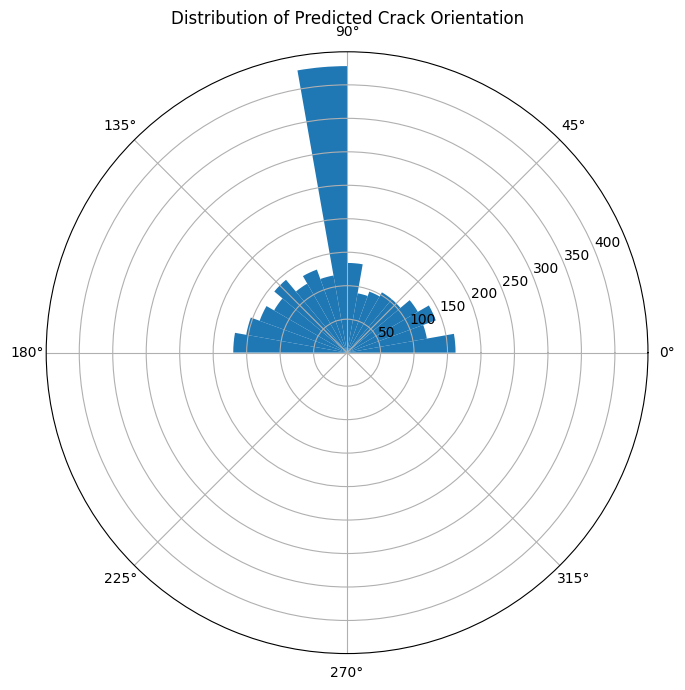

In [37]:
# Distribution of predicted crack orientation

orientation = morphology_positive_df[
    "dominant_orientation_deg"
].dropna()

theta = np.deg2rad(orientation)

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

ax.hist(
    theta,
    bins=18
)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_title(
    "Distribution of Predicted Crack Orientation",
    pad=20
)

plt.tight_layout()
plt.show()

### 10.21 Distribution of Branching Point

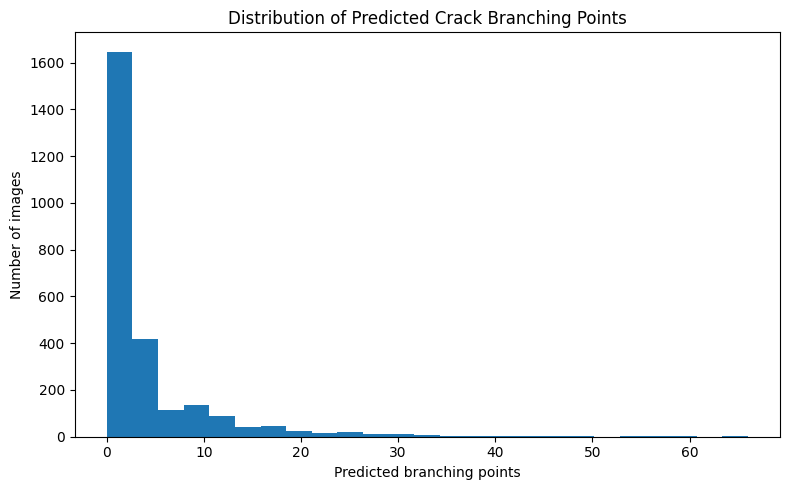

In [38]:
# Distribution of predicted crack branching points

plt.figure(figsize=(8, 5))

plt.hist(
    morphology_positive_df["branching_points"],
    bins=25
)

plt.xlabel("Predicted branching points")
plt.ylabel("Number of images")
plt.title("Distribution of Predicted Crack Branching Points")

plt.tight_layout()
plt.show()

### 10.22 Compare Morphology by Category

<Figure size 800x500 with 0 Axes>

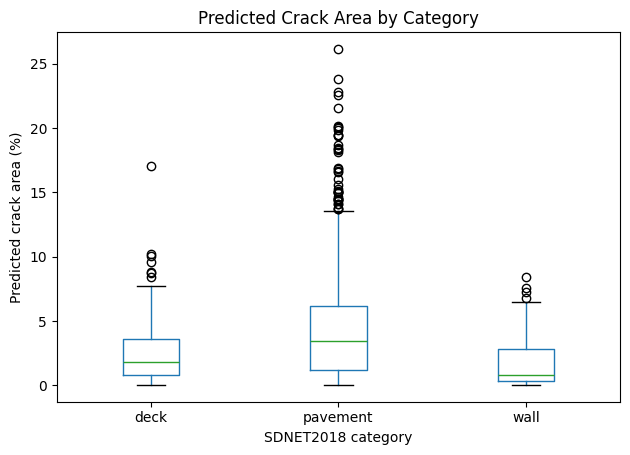

In [39]:
# Compare predicted crack area by SDNET2018 category

category_order = ["deck", "pavement", "wall"]

plt.figure(figsize=(8, 5))

morphology_positive_df.boxplot(
    column="crack_area_percentage",
    by="category",
    grid=False
)

plt.xlabel("SDNET2018 category")
plt.ylabel("Predicted crack area (%)")
plt.title("Predicted Crack Area by Category")
plt.suptitle("")

plt.tight_layout()
plt.show()

### 10.23 Category-Level Morphology Statistics

In [41]:
# Calculate morphology statistics by SDNET2018 category

category_statistics = (
    morphology_positive_df
    .groupby("category")[
        [
            "crack_area_percentage",
            "crack_length_pixels",
            "mean_width_pixels",
            "max_width_pixels",
            "branching_points"
        ]
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

category_statistics

crack_area_percentage                                          \
                         count      mean    median       std       min   
category                                                                 
deck                       595  2.338703  1.800537  1.981176  0.030518   
pavement                  1249  4.292205  3.413391  3.954661  0.030518   
wall                       757  1.573606  0.836182  1.572481  0.030518   

                    crack_length_pixels                                      \
                max               count        mean      median         std   
category                                                                      
deck      17.085266                 595  194.404702  178.409163  128.948309   
pavement  26.135254                1249  244.614620  228.592929  187.480406   
wall       8.383179                 757  205.001376  211.000000  122.479841   

          ... max_width_pixels                            branching_points  \
          ...           median        std  min        max            count   
category  ...                                                                
deck      ...        11.661904   6.729011  2.0  57.584720              595   
pavement  ...        18.973666  11.037383  2.0  72.801099             1249   
wall      ...        10.000000   5.790197  2.0  42.190046              757   

                                             
              mean median       std min max  
category                                     
deck      2.297479    0.0  3.744883   0  18  
pavement  5.695757    2.0  8.546460   0  66  
wall      1.055482    0.0  2.511263   0  23  

[3 rows x 30 columns]

### 10.24 Predicted Crack Length by Category

<Figure size 800x500 with 0 Axes>

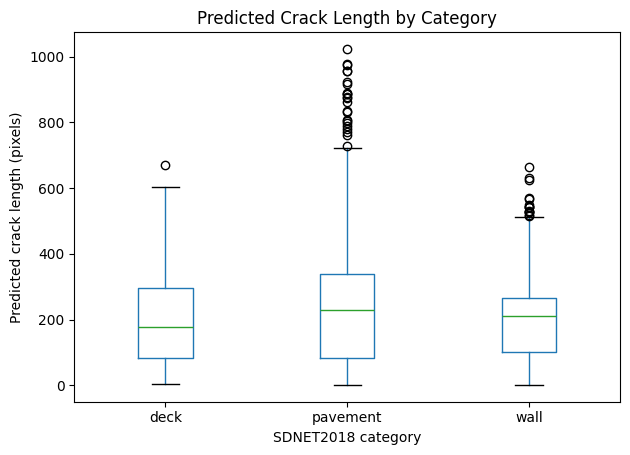

In [43]:
# Compare predicted crack length by category

plt.figure(figsize=(8, 5))

morphology_positive_df.boxplot(
    column="crack_length_pixels",
    by="category",
    grid=False
)

plt.xlabel("SDNET2018 category")
plt.ylabel("Predicted crack length (pixels)")
plt.title("Predicted Crack Length by Category")
plt.suptitle("")

plt.tight_layout()
plt.show()

### 10.25 Predicted Mean Crack Width by Category

<Figure size 800x500 with 0 Axes>

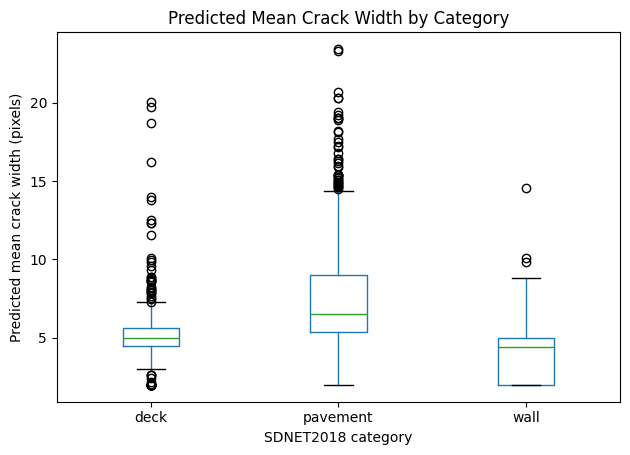

In [44]:
# Compare predicted mean crack width by category

plt.figure(figsize=(8, 5))

morphology_positive_df.boxplot(
    column="mean_width_pixels",
    by="category",
    grid=False
)

plt.xlabel("SDNET2018 category")
plt.ylabel("Predicted mean crack width (pixels)")
plt.title("Predicted Mean Crack Width by Category")
plt.suptitle("")

plt.tight_layout()
plt.show()

### 10.26 Final Morphology Statistics by Category

In [45]:
# Create the final morphology statistics table by category

morphology_variables = {
    "crack_area_percentage": "Predicted crack area (%)",
    "crack_length_pixels": "Predicted crack length (pixels)",
    "mean_width_pixels": "Predicted mean width (pixels)",
    "max_width_pixels": "Predicted maximum width (pixels)",
    "branching_points": "Predicted branching points"
}

summary_rows = []

for category in ["deck", "pavement", "wall"]:

    subset = morphology_positive_df[
        morphology_positive_df["category"] == category
    ]

    for variable, label in morphology_variables.items():

        values = subset[variable]

        summary_rows.append({
            "Category": category,
            "Morphology": label,
            "N": values.count(),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(),
            "Minimum": values.min(),
            "Q1": values.quantile(0.25),
            "Q3": values.quantile(0.75),
            "Maximum": values.max()
        })

morphology_summary = pd.DataFrame(summary_rows)

morphology_summary = morphology_summary.round(3)

morphology_summary

,Category,Morphology,N,Mean,Median,Std,Minimum,Q1,Q3,Maximum
0,deck,Predicted crack area (%),595,2.339,1.801,1.981,0.031,0.769,3.638,17.085
1,deck,Predicted crack length (pixels),595,194.405,178.409,128.948,2.828,82.234,295.779,670.465
2,deck,Predicted mean width (pixels),595,5.177,4.985,1.859,2.000,4.494,5.609,20.043
3,deck,Predicted maximum width (pixels),595,12.896,11.662,6.729,2.000,10.000,14.560,57.585
4,deck,Predicted branching points,595,2.297,0.000,3.745,0.000,0.000,4.000,18.000
5,pavement,Predicted crack area (%),1249,4.292,3.413,3.955,0.031,1.169,6.178,26.135
6,pavement,Predicted crack length (pixels),1249,244.615,228.593,187.480,2.414,84.012,339.622,1023.235
7,pavement,Predicted mean width (pixels),1249,7.435,6.525,3.061,2.000,5.376,9.020,23.417
8,pavement,Predicted maximum width (pixels),1249,21.533,18.974,11.037,2.000,13.416,28.000,72.801
9,pavement,Predicted branching points,1249,5.696,2.000,8.546,0.000,0.000,8.000,66.000


### 10.27 Create Compact Morphology Comparison Table

In [46]:
# Create a compact morphology comparison table

morphology_comparison = (
    morphology_positive_df
    .groupby("category")[
        [
            "crack_area_percentage",
            "crack_length_pixels",
            "mean_width_pixels",
            "max_width_pixels",
            "branching_points"
        ]
    ]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

morphology_comparison

crack_area_percentage                      crack_length_pixels  \
                         count   mean median    std               count   
category                                                                  
deck                       595  2.339  1.801  1.981                 595   
pavement                  1249  4.292  3.413  3.955                1249   
wall                       757  1.574  0.836  1.572                 757   

                                    mean_width_pixels                       \
             mean   median      std             count   mean median    std   
category                                                                     
deck      194.405  178.409  128.948               595  5.177  4.985  1.859   
pavement  244.615  228.593  187.480              1249  7.435  6.525  3.061   
wall      205.001  211.000  122.480               757  3.837  4.421  1.609   

         max_width_pixels                         branching_points         \
                    count    mean  median     std            count   mean   
category                                                                    
deck                  595  12.896  11.662   6.729              595  2.297   
pavement             1249  21.533  18.974  11.037             1249  5.696   
wall                  757   8.496  10.000   5.790              757  1.055   

                        
         median    std  
category                
deck        0.0  3.745  
pavement    2.0  8.546  
wall        0.0  2.511

### 10.28 Save the Morphology Results

### 10.16 Morphology Dataset Summary

In [47]:
# Save morphology datasets and summary tables

TABLES_DIR = PROJECT_ROOT / "results" / "tables"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Save complete 6,000-image dataset
morphology_df.to_csv(
    TABLES_DIR / "sdnet2018_morphology_6000.csv",
    index=False
)

# Save predicted-positive morphology dataset
morphology_positive_df.to_csv(
    TABLES_DIR / "sdnet2018_predicted_crack_morphology.csv",
    index=False
)

# Save category statistics
morphology_summary.to_csv(
    TABLES_DIR / "morphology_statistics_by_category.csv",
    index=False
)

# Save compact comparison table
morphology_comparison.to_csv(
    TABLES_DIR / "morphology_comparison_summary.csv"
)

print("Morphology results saved successfully.")

print("\nSaved files:")
print(TABLES_DIR / "sdnet2018_morphology_6000.csv")
print(TABLES_DIR / "sdnet2018_predicted_crack_morphology.csv")
print(TABLES_DIR / "morphology_statistics_by_category.csv")
print(TABLES_DIR / "morphology_comparison_summary.csv")

Morphology results saved successfully.

Saved files:
/content/concrete-crack-and-fracture-analysis/results/tables/sdnet2018_morphology_6000.csv
/content/concrete-crack-and-fracture-analysis/results/tables/sdnet2018_predicted_crack_morphology.csv
/content/concrete-crack-and-fracture-analysis/results/tables/morphology_statistics_by_category.csv
/content/concrete-crack-and-fracture-analysis/results/tables/morphology_comparison_summary.csv
